In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/base-ephys/')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from plotting import styler

In [5]:
controld49 = np.load('/Users/aidanmorson/Desktop/analysis/parkinsons/network/24481_SmitsMO_D49_sect300_20241031_acqm_results.npy', allow_pickle=True).item()
controld60 = np.load('/Users/aidanmorson/Desktop/analysis/parkinsons/network/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_acqm_results.npy', allow_pickle=True).item()
drugd49 = np.load('/Users/aidanmorson/Desktop/analysis/parkinsons/network/24578_SmitsMO_D49_sect300_20241031_acqm_results.npy', allow_pickle=True).item()
drugd60 = np.load('/Users/aidanmorson/Desktop/analysis/parkinsons/network/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_acqm_results.npy', allow_pickle=True).item()

In [6]:
print(controld49.keys())

dict_keys(['name', 'type', 'sd', 'n_bursts', 'burst_results', 'burst_edges', 'bic_matrix', 'backbone_class', 'sttc_matrix', 'sttc_threshold', 'network', 'module_membership', 'module_colors', 'network_positions'])


In [15]:
n_control49=controld49['network']
n_control60=controld60['network']
n_drug49=drugd49['network']
n_drug60=drugd60['network']

mm_control49 = controld49['module_membership']
mm_control60 = controld60['module_membership']
mm_drug49 = drugd49['module_membership']
mm_drug60 = drugd60['module_membership']

mc_control49 = controld49['module_colors']
mc_control60 = controld60['module_colors']
mc_drug49 = drugd49['module_colors']
mc_drug60 = drugd60['module_colors']

np_controld49 = controld49['network_positions']
np_controld60 = controld60['network_positions']
np_drugd49 = drugd49['network_positions']
np_drugd60 = drugd60['network_positions']


In [12]:
import networkx as nx

In [16]:
# List all networks nicely
datasets = {
    "Control D49": (n_control49, mm_control49, mc_control49, np_controld49),
    "Control D60": (n_control60, mm_control60, mc_control60, np_controld60),
    "Drug D49": (n_drug49, mm_drug49, mc_drug49, np_drugd49),
    "Drug D60": (n_drug60, mm_drug60, mc_drug60, np_drugd60)
}

# Loop and print basic stats
for name, (G, mm, mc, pos) in datasets.items():
    print(f"\n=== {name} ===")
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    avg_deg = sum(dict(G.degree()).values()) / G.number_of_nodes()
    print(f"Average Degree: {avg_deg:.2f}")
    print(f"Density: {nx.density(G):.4f}")
    print(f"Avg Clustering Coefficient: {nx.average_clustering(G):.4f}")



=== Control D49 ===
Nodes: 374
Edges: 8100
Average Degree: 43.32
Density: 0.1161
Avg Clustering Coefficient: 0.6075

=== Control D60 ===
Nodes: 160
Edges: 2132
Average Degree: 26.65
Density: 0.1676
Avg Clustering Coefficient: 0.7482

=== Drug D49 ===
Nodes: 355
Edges: 7125
Average Degree: 40.14
Density: 0.1134
Avg Clustering Coefficient: 0.6906

=== Drug D60 ===
Nodes: 236
Edges: 3238
Average Degree: 27.44
Density: 0.1168
Avg Clustering Coefficient: 0.5251


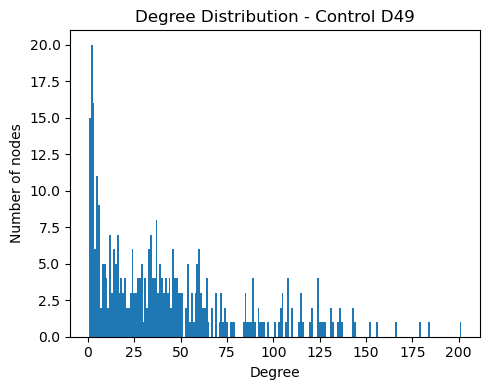

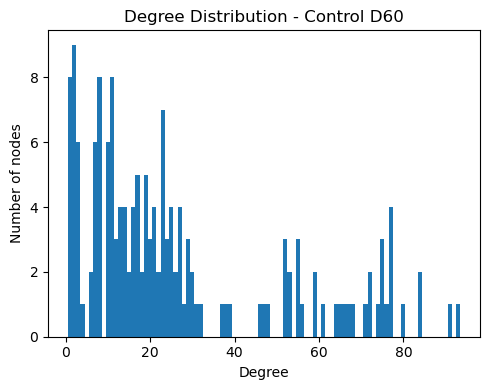

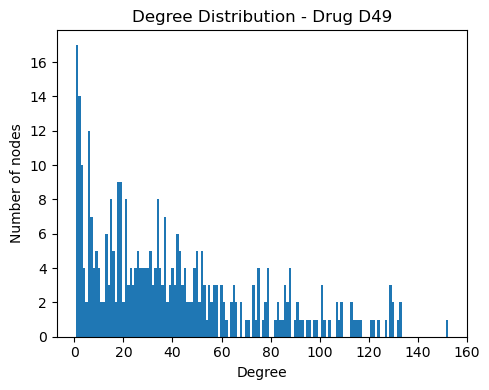

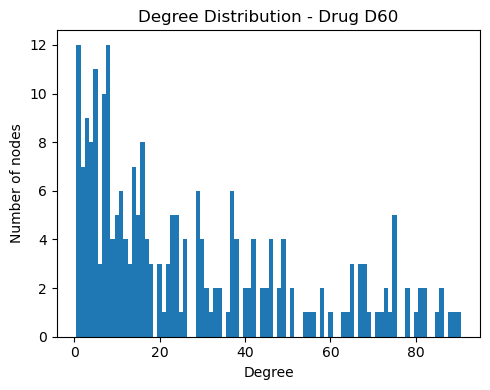

In [17]:
import matplotlib.pyplot as plt

# Plot degree histograms
for name, (G, mm, mc, pos) in datasets.items():
    degrees = [d for _, d in G.degree()]
    
    plt.figure(figsize=(5, 4))
    plt.hist(degrees, bins=range(1, max(degrees)+2), align='left')
    plt.xlabel('Degree')
    plt.ylabel('Number of nodes')
    plt.title(f'Degree Distribution - {name}')
    plt.tight_layout()
    plt.show()


In [18]:
import numpy as np

# Print number of nodes in each module
for name, (G, mm, mc, pos) in datasets.items():
    modules = list(mm.values())
    unique_modules, counts = np.unique(modules, return_counts=True)
    
    print(f"\n=== Module Summary for {name} ===")
    for mod, count in zip(unique_modules, counts):
        print(f"Module {mod}: {count} nodes")



=== Module Summary for Control D49 ===
Module -1: 29 nodes
Module 0: 2 nodes
Module 1: 2 nodes
Module 2: 3 nodes
Module 3: 3 nodes
Module 4: 2 nodes
Module 5: 2 nodes
Module 6: 2 nodes
Module 7: 2 nodes
Module 8: 211 nodes
Module 9: 142 nodes
Module 10: 3 nodes

=== Module Summary for Control D60 ===
Module -1: 47 nodes
Module 0: 153 nodes
Module 1: 2 nodes
Module 2: 2 nodes
Module 3: 3 nodes

=== Module Summary for Drug D49 ===
Module -1: 23 nodes
Module 0: 3 nodes
Module 1: 6 nodes
Module 2: 2 nodes
Module 3: 3 nodes
Module 4: 2 nodes
Module 5: 4 nodes
Module 6: 2 nodes
Module 7: 41 nodes
Module 8: 2 nodes
Module 9: 2 nodes
Module 10: 2 nodes
Module 11: 2 nodes
Module 12: 2 nodes
Module 13: 22 nodes
Module 14: 2 nodes
Module 15: 2 nodes
Module 16: 245 nodes
Module 17: 8 nodes
Module 18: 3 nodes

=== Module Summary for Drug D60 ===
Module -1: 19 nodes
Module 0: 10 nodes
Module 1: 3 nodes
Module 2: 160 nodes
Module 3: 2 nodes
Module 4: 2 nodes
Module 5: 20 nodes
Module 6: 4 nodes
Modu

/var/folders/y8/kbj1jbfx1tz288yn1q1ssj4r0000gn/T/ipykernel_28671/4244752574.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


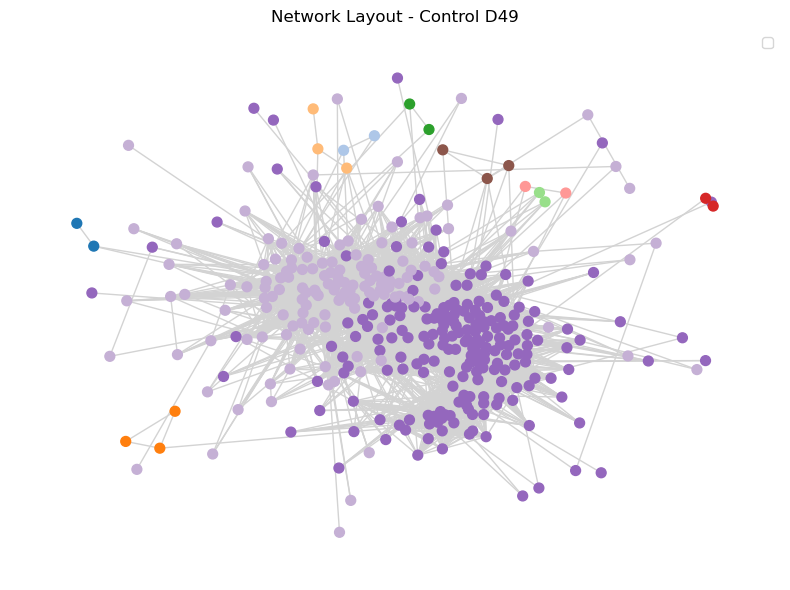

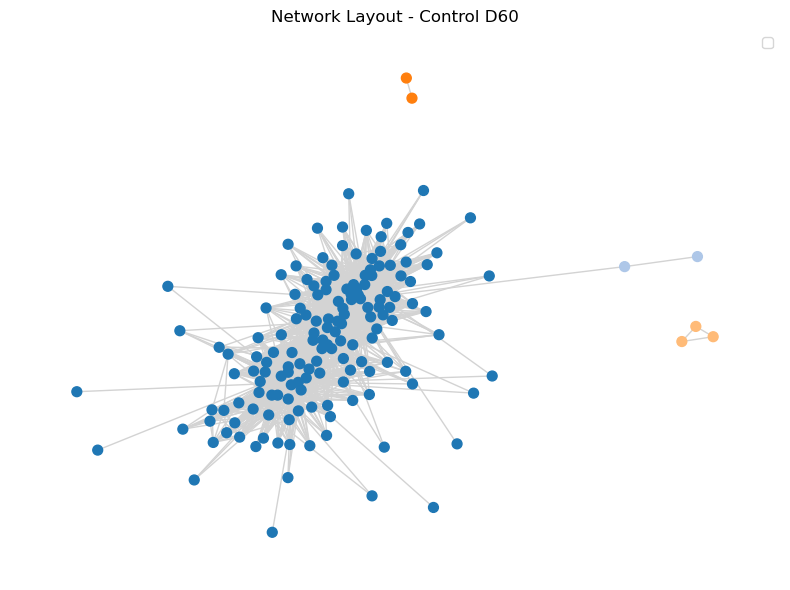

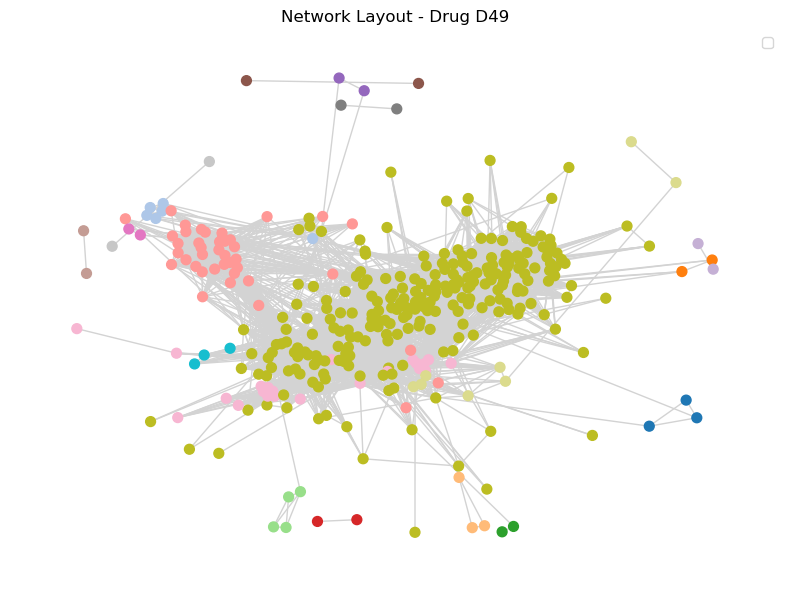

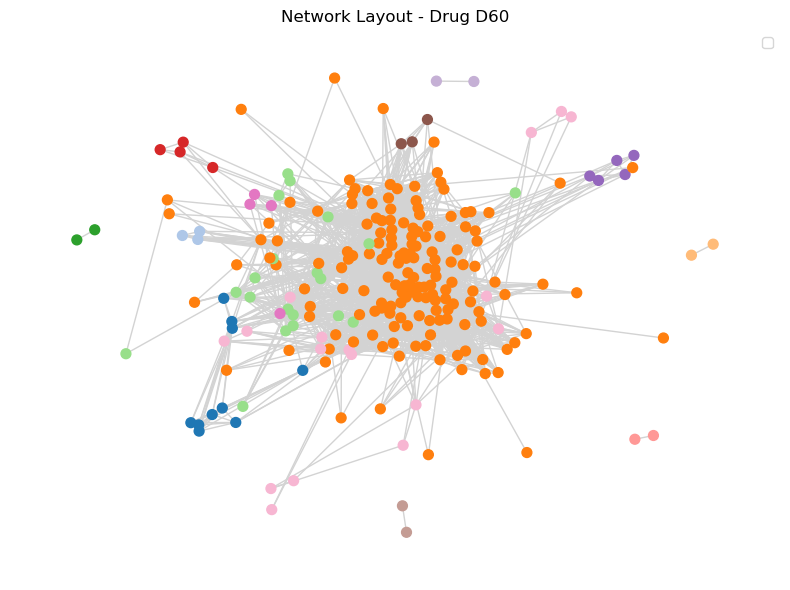

In [23]:
# Plot each network colored by module
for name, (G, mm, mc, pos) in datasets.items():
    node_colors = [mc.get(mm.get(n, -1), '#CCCCCC') for n in G.nodes()]
    
    plt.figure(figsize=(8, 6))
    nx.draw_networkx(
        G, pos=pos, node_color=node_colors, 
        node_size=50, edge_color='lightgray', with_labels=False
    )
    plt.title(f'Network Layout - {name}')
    plt.axis('off')
    plt.tight_layout()
    plt.legend()
    plt.show()


In [20]:
for name, (G, mm, mc, pos) in datasets.items():
    modules = list(mm.values())
    unique_modules = set(modules) - {-1}
    print(f"{name}: {len(unique_modules)} modules detected")


Control D49: 11 modules detected
Control D60: 4 modules detected
Drug D49: 19 modules detected
Drug D60: 14 modules detected


In [32]:
from networkx.algorithms import community as nx_comm

n_drug49_1 = nx_comm.louvain_communities(n_drug49, resolution=1.0)
n_drug49_05 = nx_comm.louvain_communities(n_drug49, resolution=0.5)
n_drug49_2 = nx_comm.louvain_communities(n_drug49, resolution=2.0)
print(f"Found {len(n_drug49_1)} modules in drug day 49 with resolution 1.0")
print(f"Found {len(n_drug49_05)} modules in drug day 49 with resolution 0.5")
print(f"Found {len(n_drug49_2)} modules in drug day 49 with resolution 2.0")

n_drug60_1 = nx_comm.louvain_communities(n_drug60, resolution=1.0)
n_drug60_05 = nx_comm.louvain_communities(n_drug60, resolution=0.5)
n_drug60_2 = nx_comm.louvain_communities(n_drug60, resolution=2.0)
print(f"Found {len(n_drug60_1)} modules in drug day 60 with resolution 1.0")
print(f"Found {len(n_drug60_05)} modules in drug day 60 with resolution 0.5")
print(f"Found {len(n_drug60_2)} modules in drug day 60 with resolution 2.0")


n_control49_1 = nx_comm.louvain_communities(n_control49, resolution=1.0)
n_control49_05 = nx_comm.louvain_communities(n_control49, resolution=0.5)
n_control49_2 = nx_comm.louvain_communities(n_control49, resolution=2.0)
print(f"Found {len(n_control49_1)} modules in control day 49 with resolution 1.0")
print(f"Found {len(n_control49_05)} modules in control day 49 with resolution 0.5")
print(f"Found {len(n_control49_2)} modules in control day 49 with resolution 2.0")

n_control60_1 = nx_comm.louvain_communities(n_control60, resolution=1.0)
n_control60_05 = nx_comm.louvain_communities(n_control60, resolution=0.5)
n_control60_2 = nx_comm.louvain_communities(n_control60, resolution=2.0)

print(f"Found {len(n_control60_1)} modules in control day 60 with resolution 1.0")
print(f"Found {len(n_control60_05)} modules in control day 60 with resolution 0.5")
print(f"Found {len(n_control60_2)} modules in control day 60 with resolution 2.0")


# (Then reassign module_membership if needed)


Found 21 modules in drug day 49 with resolution 1.0
Found 20 modules in drug day 49 with resolution 0.5
Found 29 modules in drug day 49 with resolution 2.0
Found 20 modules in drug day 60 with resolution 1.0
Found 15 modules in drug day 60 with resolution 0.5
Found 31 modules in drug day 60 with resolution 2.0
Found 19 modules in control day 49 with resolution 1.0
Found 14 modules in control day 49 with resolution 0.5
Found 26 modules in control day 49 with resolution 2.0
Found 6 modules in control day 60 with resolution 1.0
Found 5 modules in control day 60 with resolution 0.5
Found 23 modules in control day 60 with resolution 2.0


In [30]:
componetsd49 = list(nx.connected_components(n_drug49))
print(f"Drug D49 has {len(componetsd49)} connected components.")
componentsd60 = list(nx.connected_components(n_drug60))
print(f"Drug D60 has {len(componentsd60)} connected components.")

componentsc49 = list(nx.connected_components(n_control49))
print(f"Control D49 has {len(componentsc49)} connected components.")
componentsc60 = list(nx.connected_components(n_control60))
print(f"Control D60 has {len(componentsc60)} connected components.")

Drug D49 has 8 connected components.
Drug D60 has 6 connected components.
Control D49 has 1 connected components.
Control D60 has 3 connected components.


In [1]:
from networkx.algorithms import community as nx_comm

print("\n=== Modularity Scores ===")
for name, (G, mm, mc, pos) in datasets.items():
    # Group nodes by module
    modules = {}
    for node, mod_id in mm.items():
        modules.setdefault(mod_id, []).append(node)
    
    community_list = list(modules.values())
    
    modularity = nx_comm.modularity(G, community_list)
    print(f"{name}: Modularity = {modularity:.4f}")



=== Modularity Scores ===


NameError: name 'datasets' is not defined

In [34]:
# Save module sizes to plot later
module_sizes = {}

for name, (G, mm, mc, pos) in datasets.items():
    modules = {}
    for node, mod_id in mm.items():
        modules.setdefault(mod_id, []).append(node)
    
    sizes = [len(nodes) for nodes in modules.values()]
    module_sizes[name] = sizes


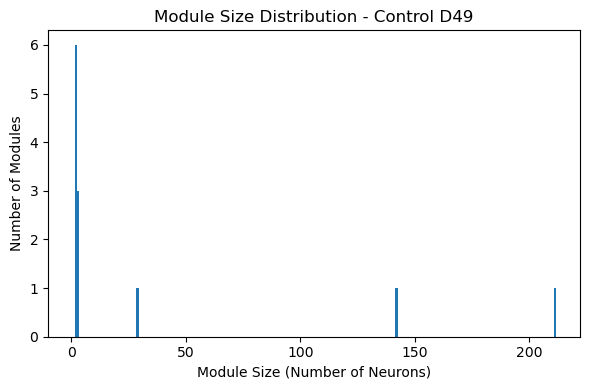

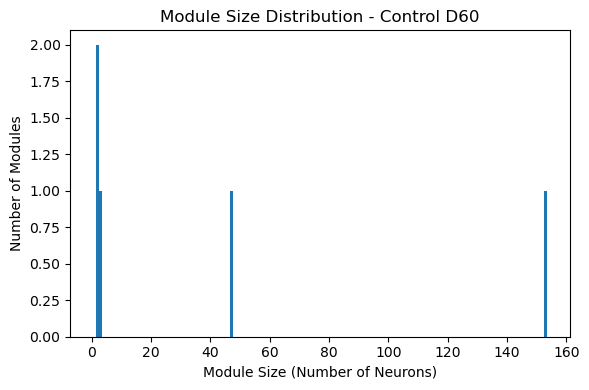

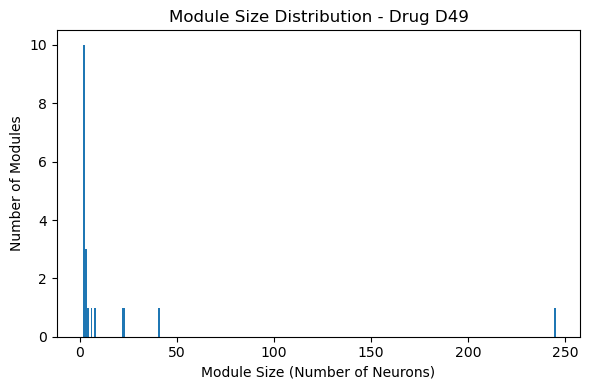

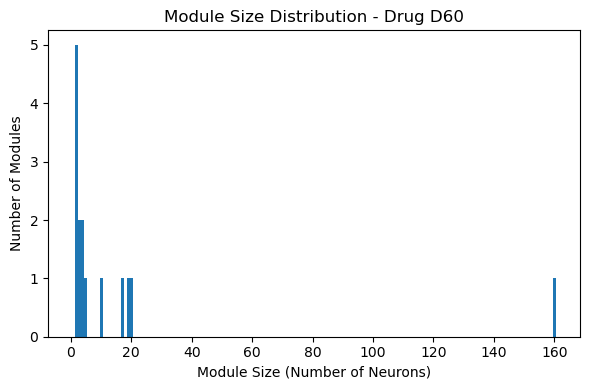

In [35]:
import matplotlib.pyplot as plt

# Plot histograms
for name, sizes in module_sizes.items():
    plt.figure(figsize=(6, 4))
    plt.hist(sizes, bins=range(1, max(sizes)+2), align='left')
    plt.xlabel('Module Size (Number of Neurons)')
    plt.ylabel('Number of Modules')
    plt.title(f'Module Size Distribution - {name}')
    plt.tight_layout()
    plt.show()
